https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

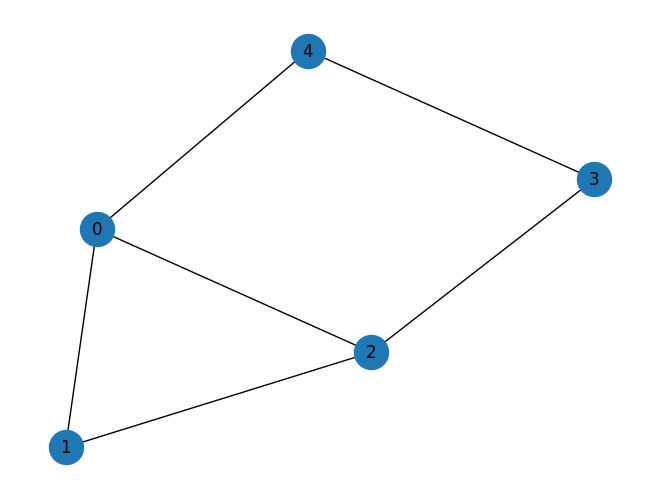

In [99]:
n = 5

# Rustworkx (rx) is a package IBM developed for qiskit
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

In [ ]:
Maximize
 -2*x_0*x_1 - 2*x_0*x_2 - 2*x_0*x_4 - 2*x_1*x_2 - 2*x_2*x_3 - 2*x_3*x_4 + 3*x_0
 + 2*x_1 + 3*x_2 + 2*x_3 + 2*x_4

Subject to
  No constraints

  Binary variables (5)
    x_0 x_1 x_2 x_3 x_4

min_x∈{0,1}^n (x^T Qx)

In [53]:
def build_max_cut_paulis(
    graph: rx.PyGraph,
) -> list[tuple[str, list[int], float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


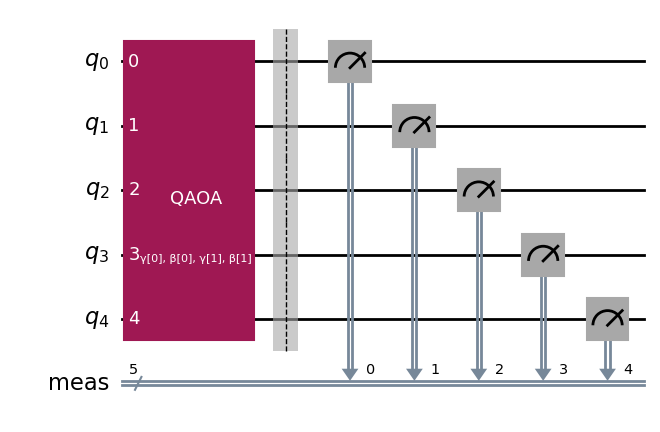

In [54]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

In [55]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [58]:
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-03-10 20:08:55,953: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


qiskit_runtime_service.__init__:WARNING:2026-03-12 16:26:54,692: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-12 16:26:55,282: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-12 16:26:57,045: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


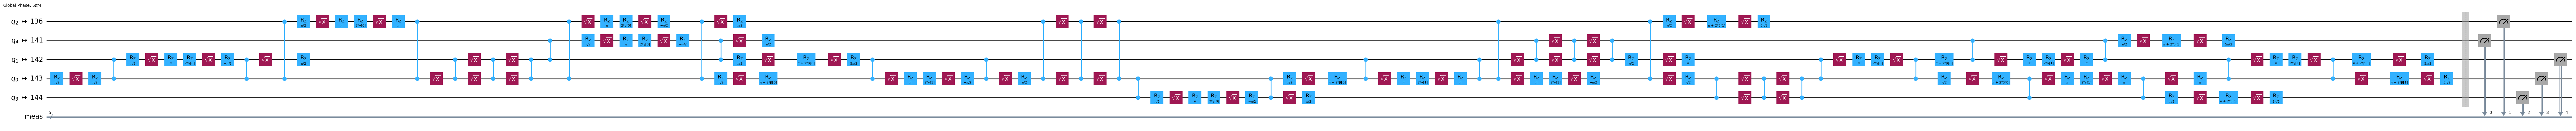

In [86]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

# Try a local simulator -- not doing this anymore.  I think Session is the problem
from qiskit.providers.fake_provider import GenericBackendV2
backend = GenericBackendV2(num_qubits=156)

Well, that didn't work because i needed to make a 154 bit backend!  I could, but have no idea what to do for the coupling map
Another tack is to try a different type of session.  Ahh.  The Session instance is what is the problem

In [84]:
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [78]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [85]:
objective_func_vals = []  # Global variable
with Session(backend=backend) as session:# Indeed, this does the ofending 
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=backend)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

IBMInputValueError: 'The instruction cz on qubits (143, 142) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'

This should work in job mode with Estimator(mode=backend) according to https://quantum.cloud.ibm.com/docs/en/guides/primitives-examples but it is taking a very long time

In [88]:
objective_func_vals = []  # Global variable

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
estimator = Estimator(mode=backend)
estimator.options.default_shots = 1000

# Set simple error suppression/mitigation options
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = "auto"

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-2,
)
print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.9451366736315616
       x: [ 2.733e+00  1.890e+00  3.577e+00  4.282e+00]
    nfev: 30
   maxcv: 0.0


In [89]:
 backend

<IBMBackend('ibm_fez')>

That ended up taking 5min of my 10min free time for the month.  fez is 156 bit qpu in the Heron r2 series

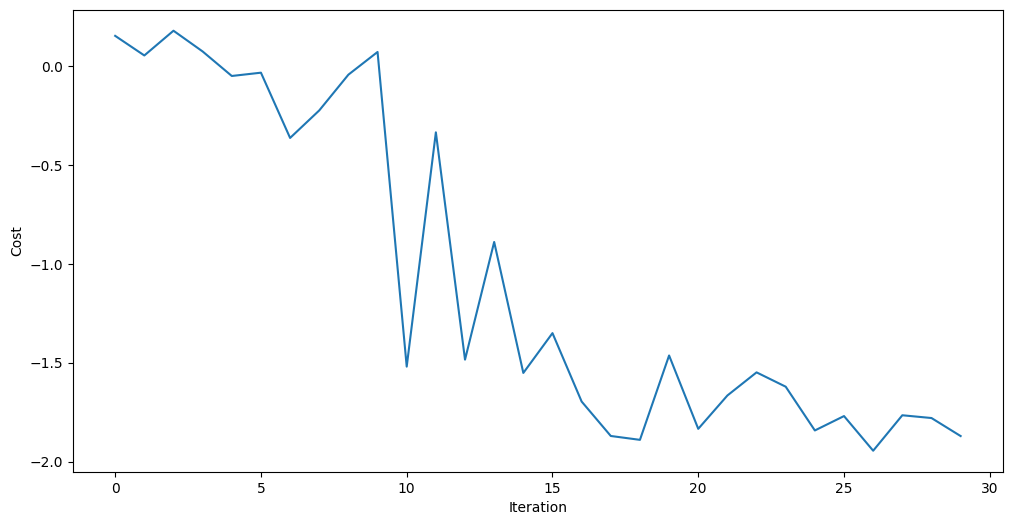

In [90]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

As per instructions, the x parameters get fed back into the circuit and the circuit run again in sampling mode

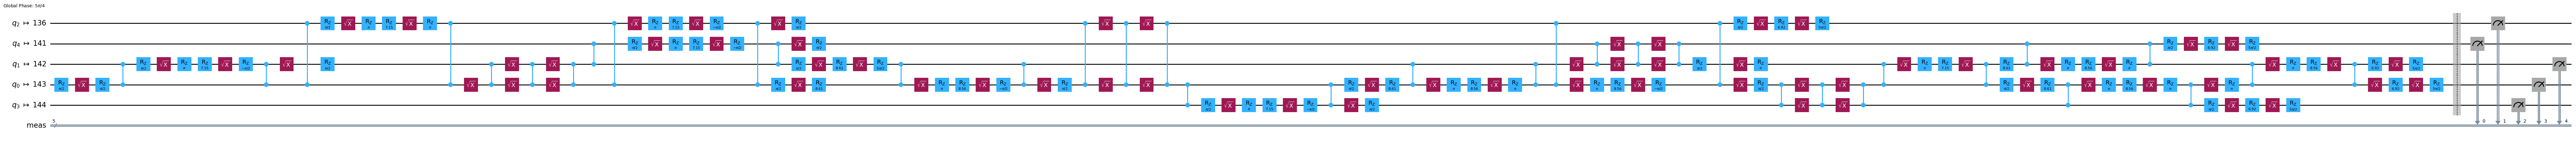

In [91]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

Looks different than tutorial, but my cost function was lower & the specific parameters different

In [92]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{25: 0.0281, 9: 0.0855, 5: 0.0923, 12: 0.0271, 14: 0.0239, 11: 0.0824, 22: 0.0748, 20: 0.0911, 3: 0.0244, 19: 0.0254, 21: 0.0425, 0: 0.0061, 2: 0.0078, 13: 0.0416, 26: 0.0954, 30: 0.0083, 1: 0.0087, 31: 0.0063, 17: 0.0252, 7: 0.0089, 6: 0.0237, 24: 0.0073, 23: 0.0072, 18: 0.0423, 10: 0.04, 16: 0.0068, 4: 0.01, 28: 0.0249, 29: 0.0096, 15: 0.0059, 27: 0.0084, 8: 0.0081}


Estimated runtime for this is 6s, but taking a while to queue up 6:12pm or so, finished around 6:18, but only took 8s of CPU.  Not sure where all my 5 minutes of time went.  Ahh.  They don't list all of the jobs unless you fiddle with the display number at https://quantum.cloud.ibm.com/

In [93]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 1, 1]


In [94]:
counts_int

{25: 281,
 9: 855,
 5: 923,
 12: 271,
 14: 239,
 11: 824,
 22: 748,
 20: 911,
 3: 244,
 19: 254,
 21: 425,
 0: 61,
 2: 78,
 13: 416,
 26: 954,
 30: 83,
 1: 87,
 31: 63,
 17: 252,
 7: 89,
 6: 237,
 24: 73,
 23: 72,
 18: 423,
 10: 400,
 16: 68,
 4: 100,
 28: 249,
 29: 96,
 15: 59,
 27: 84,
 8: 81}

In [95]:
counts_bin

{'11001': 281,
 '01001': 855,
 '00101': 923,
 '01100': 271,
 '01110': 239,
 '01011': 824,
 '10110': 748,
 '10100': 911,
 '00011': 244,
 '10011': 254,
 '10101': 425,
 '00000': 61,
 '00010': 78,
 '01101': 416,
 '11010': 954,
 '11110': 83,
 '00001': 87,
 '11111': 63,
 '10001': 252,
 '00111': 89,
 '00110': 237,
 '11000': 73,
 '10111': 72,
 '10010': 423,
 '01010': 400,
 '10000': 68,
 '00100': 100,
 '11100': 249,
 '11101': 96,
 '01111': 59,
 '11011': 84,
 '01000': 81}

Ah.  _bin and _int correspond to the binary notation for the bits vs int notation.  These dicts are the fundamental output of the Sampler measurement.  Actually, not quite.  A decision was made to munge the output into these dicts rather than a list of dicts that could have been made into a Table of some sort (pandas or astropy).  Abstraction is violated by using the original values to pick indices back into the dict, which are really not intended to be indexed by number but rather by key.  Determining how best to store these would be a group decision.

Actually, it looks like this is a primitive quiskit decision.  The data.meas.get_*() methods used return a dict.  They just fiddle the val to normalize to shots.

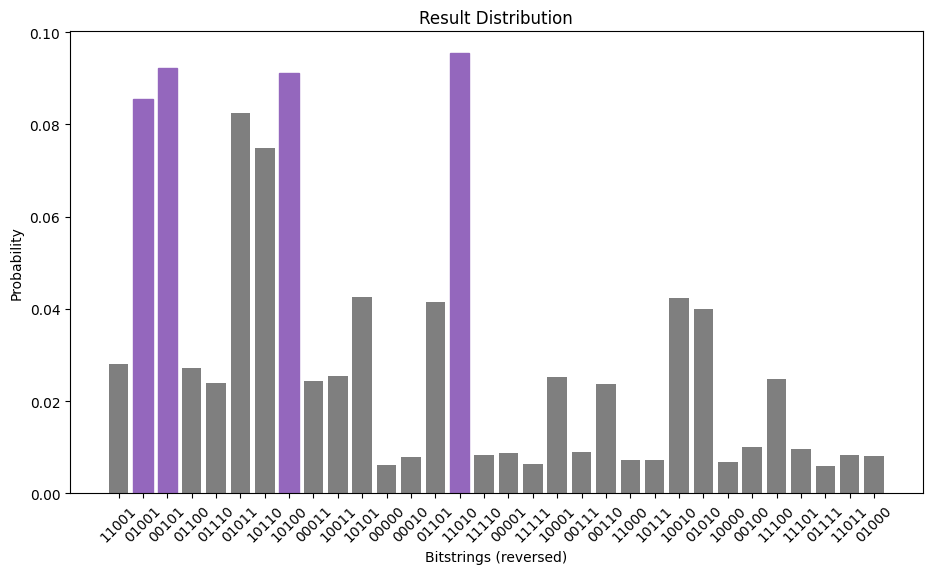

In [97]:
matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
# There's probably a more pythonic way to do this
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

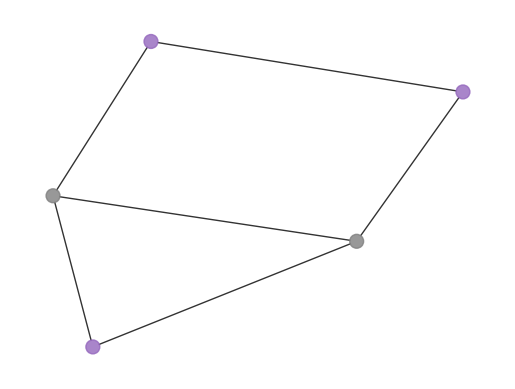

In [98]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

In [100]:
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )


cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

The value of the cut is: 4


Not too max! :-(  Expecting 5.
The problem is that post-processing isn't sophistiscated enough to make up for the fuzziness of the quauntum calculation
I want some better handles on the results.  Back up to when the most_likely_bitstring was selected.  I really want a numpy.argsort set of indicies into values (the figure of merit), but they don't do it that way.  Rather they hack through the values of the dict return from Sampler to get positions.  We should make some likely_bitstring values based on those

In [144]:
for p in positions:
    # np.flatnonzero(p) or better handling of np.argsort can clean this up
    likely = keys[p[0]]
    # Ah.  This is a bit list actually.  Could potentially do this using clever string processing of counts_bin(keys)
    bitstring = to_bitstring(likely, len(graph))
    cut_value = evaluate_sample(bitstring, graph)
    print(f'bitstring: {bitstring} number of cuts: {cut_value}')

bitstring: [1, 1, 0, 1, 0] number of cuts: 5
bitstring: [0, 0, 1, 0, 1] number of cuts: 5
bitstring: [1, 0, 1, 0, 0] number of cuts: 4
bitstring: [0, 1, 0, 0, 1] number of cuts: 4


In [146]:
d = job.result()[0].data

In [149]:
d.meas

BitArray(<shape=(), num_shots=10000, num_bits=5>)

In [150]:
job.result()[0].data

DataBin(meas=BitArray(<shape=(), num_shots=10000, num_bits=5>))

In [151]:
d.meas.array

array([[25],
       [ 9],
       [ 9],
       ...,
       [ 5],
       [26],
       [ 9]], shape=(10000, 1), dtype=uint8)

In [155]:
d.meas.bitcount()

array([3, 2, 2, ..., 2, 3, 2], shape=(10000,), dtype=uint64)

In [138]:
np.flatnonzero(positions)

array([0, 1, 2, 3])